In [62]:
from class_heatflux import HeatFluxAnalyzer
import pickle
import matplotlib.pyplot as plt
from function_calculation import cut_2d_array_by_threshold, approximation_cutoff
import numpy as np
from functools import partial
from scipy.optimize import curve_fit



In [63]:
with open("T_dict.pkl", "rb") as f:
    T_dict = pickle.load(f)
with open("x_axis_half.pkl", "rb") as f:
    x_axis_half = pickle.load(f)

In [64]:
k_extract_pix_phase_from_top = 500
T_room = 24.5
n_apr_pix = 700

In [65]:
heatfluxanalyzer = HeatFluxAnalyzer(
    T_dict,
    x_axis_half,
    k_extract_pix_phase_from_top,
    T_room,
    0.05,
    int(n_apr_pix),
    T_room
    )

In [66]:
T_full_array_cutoff_dict = heatfluxanalyzer.temp_full_array_cutoff_dict


In [67]:
keys = T_full_array_cutoff_dict.keys()
print(keys)

dict_keys(['offset', 'offset_convolve', 'gaussian_plus_linear', 'gaussian_plus_linear_centered', 'gaussian_plus_offset', 'gaussian_plus_offset_centered'])


In [68]:
temp_apr_dict = {}
popt_full_dict = {}
popt_init_full_dict = {}

d_micro_to_pix_temp = 1.9833
# del T_full_array_cutoff_dict['offset']


n_params = 2
n_params = 4
from function_calculation import estimate_initial_gaussian_params_cutoff_temp,gaussian_centered,gaussian_plus_linear_centered


In [69]:
def  gaussian_plus_parabola_centered(x, A, sigma, a, c):
    return A * np.exp(-(x ** 2) / (2 * sigma ** 2)) + a * x**2 + c


def estimate_initial_gaussian_params_cutoff_temp_parabola(x, y):
    """
    x: 1D array, x data
    y: 1D array, y data

    戻り値: A_init, mu_init, sigma_init, b_init
    """

    # 振幅初期値: 最大値 - オフセット
    A_init = np.max(y)

    # 中心位置初期値: 最大値のx位置
    # mu_init = x[np.argmax(y)]

    # σ初期値: 分散の重み付き平均で推定
    y_adj = y
    y_adj[y_adj < 0] = 0  # 負値はゼロにする

    if np.sum(y_adj) == 0:
        sigma_init = 1.0  # 適当な値
    else:
        mu_weighted = np.sum(x * y_adj) / np.sum(y_adj)
        sigma_init = np.sqrt(np.sum(y_adj * (x - mu_weighted) ** 2) / np.sum(y_adj))

    # 二次関数フィッティング（一次項なし）
    coeffs = np.polyfit(x, y, 2)
    a_init = coeffs[0]
    c_init = coeffs[2]
    return A_init, sigma_init, a_init, c_init

In [70]:
# func_estimate = estimate_initial_gaussian_params_cutoff_temp
func_estimate = estimate_initial_gaussian_params_cutoff_temp_parabola
# func_approx = gaussian_centered
func_approx = gaussian_plus_parabola_centered
popt_full = np.zeros((n_apr_pix, n_params))
popt_init_full = np.zeros((n_apr_pix, n_params))

# popt_init_names = ["A_init", "sigma_init"]
popt_names = ["A_init", "sigma_init", "m", "b"]
popt_names = ["A_init", "sigma_init", "a_init", "c_init"]

popt_names = ["A", "sigma"]
popt_names = ["A", "sigma", "a", "c"]

#* T_roomを固定した関数を作成
# func_approx = partial(gaussian_plus_offset_fixed_b, T_room=T_room)
# print(type(T_full_array_cutoff_dict['offset_convolve']))
# # twolist_array = np.array(T_full_array_cutoff_dict['offset_convolve']) -  T_room
# twolist_array = [
#     np.array(row) - T_room
#     for row in T_full_array_cutoff_dict['offset_convolve']
# ]
# twolist_array = T_full_array_cutoff_dict['gaussian_plus_linear_centered']
# twolist_x_axis = heatfluxanalyzer.x_axis_cutoff_dict['gaussian_plus_linear_centered']
twolist_array = T_full_array_cutoff_dict['offset_convolve']
twolist_x_axis = heatfluxanalyzer.x_axis_cutoff_dict['offset_convolve']

for i in range(len(twolist_array)):
    len_array = len(twolist_array[i])
    len_x_axis = len(twolist_x_axis[i])
# ポイント

# array_obj = np.array(twolist_x_axis, dtype=object)
# print("len:", len(array_obj))
# for i, row in enumerate(array_obj):
#     print(f"Row {i} length: {len(row)}",  heatfluxanalyzer.x_axis_cutoff_dict)


temp_apr = np.empty(n_apr_pix, dtype=object)

for i in range(n_apr_pix):
    width_temp = len(twolist_array[i])  # 横方向のピクセル
    temp_apr[i] = np.zeros(width_temp)
    x_axis = twolist_x_axis[i]  # 横方向のピクセル
    array_y = np.array(twolist_array[i]) - T_room
    #* 初期パラメータの推定
    A_init, sigma_init, a_init, c_init = func_estimate(x_axis, array_y)
    # print("x_axis.shape:", x_axis.shape, "array_y.shape:", array_y.shape)
    
    #* フィッティング（ガウシアン+ 一次関数）
    popt, _ = curve_fit(func_approx, x_axis, array_y, maxfev=20000,
                        p0=[A_init, sigma_init, a_init, c_init],
                        # bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf])
                        )
    # popt_init_full[i] = [A_init, mu_init, sigma_init]
    # popt_full[i] = popt  # フィッティング結果を格納
    # print("A_init:", A_init, "sigma_init:", sigma_init)
    # print("A:", popt[0], "sigma:", popt[1])
    popt_init_full[i] = [A_init, sigma_init, a_init, c_init]
    popt_full[i] = popt  # フィッティング結果を格納

# 各フェーズデータを計算し、対応する配列に格納
    A, sigma, a, c = popt_full[i]
    y_values = func_approx(x_axis, A, sigma, a, c) + T_room
    temp_apr[i] = y_values  # 横方向に格納

    print(f"Index {i}: len(twolist_array) = {len(twolist_array[i])}, len(twolist_x_axis) = {len(twolist_x_axis[i])}, len(temp_apr[i]) = {len(temp_apr[i])}")
print(popt_init_full[600])
print(popt_full[600])

# for key, array in T_full_array_cutoff_dict.items():
#     n_params = 3
#     from function_calculation import estimate_initial_gaussian_params_cutoff_temp,gaussian_plus_offset_fixed_b
#     func_estimate = estimate_initial_gaussian_params_cutoff_temp
#     func_approx = gaussian_plus_offset_fixed_b
#     popt_full = np.zeros((n_apr_pix, n_params))
#     popt_init_full = np.zeros((n_apr_pix, n_params))

#     popt_names = ["A", "mu", "sigma"]
#     popt_init_names = ["A_init", "mu_init", "sigma_init"]

#     #* T_roomを固定した関数を作成
#     func_approx = partial(gaussian_plus_offset_fixed_b, T_room=T_room)
    
#     twolist_array = array
#     for i in range(n_apr_pix):
#         width_temp = len(twolist_array[i])  # 横方向のピクセル
#         temp_apr = np.zeros((n_apr_pix, width_temp))  # 4つのフェーズデータをまとめて作成
#         array_y = np.array(twolist_array[i])
#         x_axis = np.arange(width_temp)
#         #* 初期パラメータの推定
#         A_init, mu_init, sigma_init = func_estimate(x_axis, array_y, T_room)
#         print("A_init:", A_init, "mu_init:", mu_init, "sigma_init:", sigma_init)
#         print("x_axis.shape:", x_axis.shape, "array_y.shape:", array_y.shape)
        
#         #* フィッティング（ガウシアン+ 一次関数）
#         popt, _ = curve_fit(func_approx, x_axis, array_y, maxfev=20000,
#                             p0=[A_init, mu_init, sigma_init],
#                             )
#         popt_init_full[i] = [A_init, mu_init, sigma_init]
#         popt_full[i] = popt  # フィッティング結果を格納



Index 0: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 1: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 2: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 3: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 4: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 5: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 6: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 7: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 8: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 9: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 10: len(twolist_array) = 489, len(twolist_x_axis) = 489, len(temp_apr[i]) = 489
Index 11: len(twolist_array) = 489, len(twolist_x_axis) = 489, l

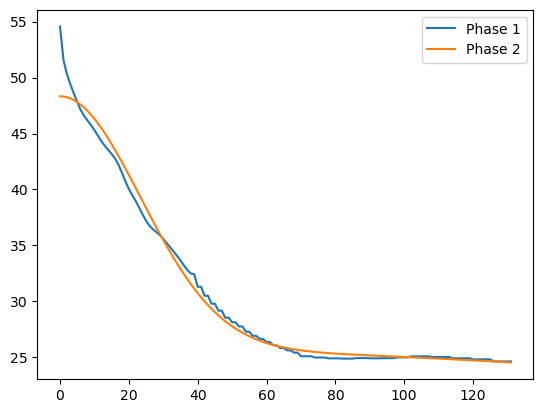

[3.00662518e+01 2.10726212e+01 2.96837428e-03 2.57770350e+01]
[ 2.26142803e+01  2.32372629e+01 -6.83767688e-05  1.21128682e+00]


In [75]:
# for key, array in T_full_array_cutoff_dict.items():
#     fig = plt.figure()
#     plt.plot(array[k_extract_pix_phase_from_top], label = {key})
#     plt.axhline(y=T_room, color='k', linestyle='--',label = 'T = 24.5')  # T=24.5の水平線を引く
#     plt.legend()
#     plt.show()
x_axis_half = x_axis_half[:len(T_full_array_cutoff_dict['offset_convolve'][600])]
fig = plt.figure()
plt.plot(twolist_x_axis[600], T_full_array_cutoff_dict['offset_convolve'][600], label = "Phase 1")
plt.plot(twolist_x_axis[600], temp_apr[600], label = "Phase 2")
plt.legend()
plt.show()

print(popt_init_full[600])
print(popt_full[600])
# print(T_full_array_cutoff_dict['offset_convolve'])

In [72]:
import numpy as np
Nx = 40
width_phase = 200  # 横方向のピクセル数
x_axis = np.arange(-Nx, -Nx + width_phase)
print(x_axis)

[-40 -39 -38 -37 -36 -35 -34 -33 -32 -31 -30 -29 -28 -27 -26 -25 -24 -23
 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5
  -4  -3  -2  -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13
  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31
  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49
  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139
 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157
 158 159]


In [73]:
l = 20
img_phase_array_slice = x_axis[Nx:-l]
print(img_phase_array_slice)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139]


In [74]:
img_phase_array_slice = x_axis[l:Nx] #TODO 左半分
print(img_phase_array_slice)

[-20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3
  -2  -1]
